**dataset**:  https://drive.google.com/file/d/1vGbcKiuxyy_REKkia2A0mBU-nG-pXZ-L/view?usp=sharing

**step1**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Step 2: loading the dataset**

In [ ]:
df = pd.read_csv('/content/Flight_Booking - Flight_Booking (1).csv')

In [ ]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [ ]:
df  = df.drop(columns =['Unnamed: 0'])

In [ ]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [ ]:
# brief summary of the data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [ ]:
#cheaking null
df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


In [ ]:
#cheaking for duplicate
df.duplicated().sum()

np.int64(531)

In [ ]:
#droping dupicates
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

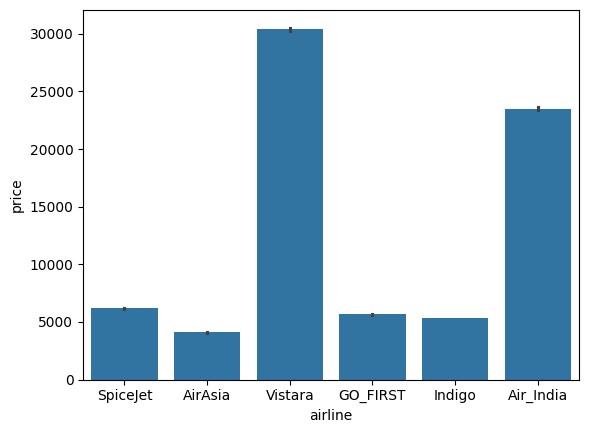

In [ ]:
#visualization of price as per airlines
sns.barplot(data=df,x='airline',y='price')
plt.show()


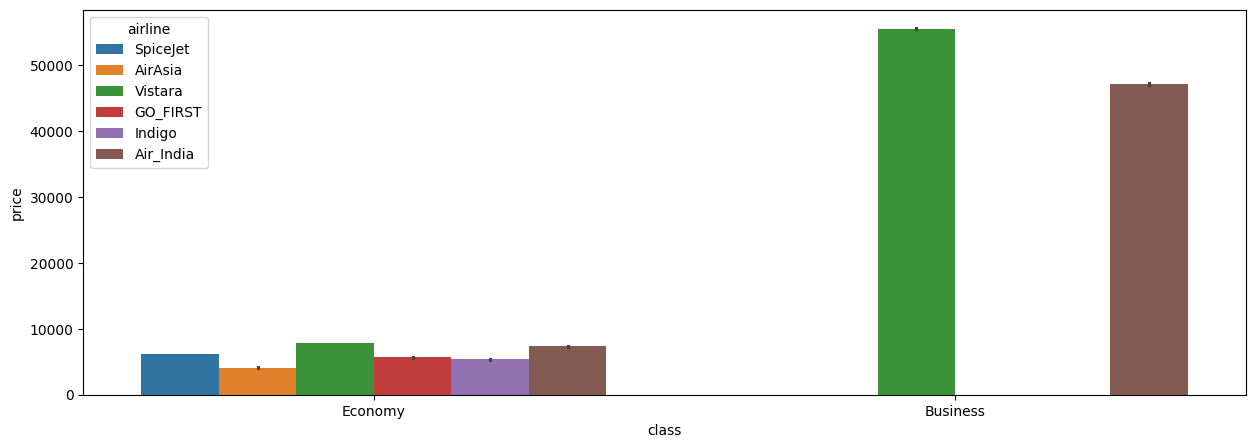

In [ ]:
#visualization of price of class as per airline
plt.figure(figsize =(15, 5))
sns.barplot(x ='class', y ='price', hue ='airline', data = df)
plt.show()

In [ ]:
# check economy and business class range
print(f"Economy class price range: ${df[df['class']== 'Economy']['price'].min():.2f} -  ${df[df['class']== 'Economy']['price'].max():.2f}")

Economy class price range: $1105.00 -  $42349.00


In [ ]:
# check economy and business class range
print(f"business  class price range: ${df[df['class']== 'Business']['price'].min():.2f} -  ${df[df['class']== 'Business']['price'].max():.2f}")

business  class price range: $12000.00 -  $123071.00


<Axes: xlabel='days_left', ylabel='price'>

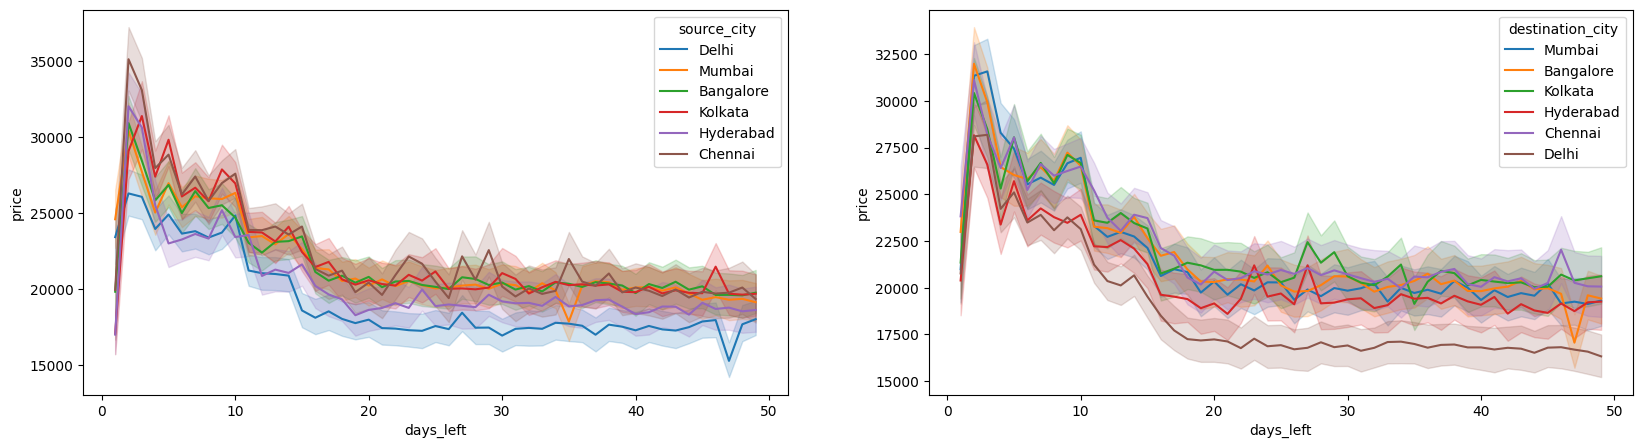

In [ ]:
#visualzation of price by day left in price
fig, ax = plt.subplots(1, 2, figsize =(20, 5))
sns.lineplot(x ='days_left', y ='price', hue ='source_city', data = df, ax = ax[0])
sns.lineplot(x ='days_left', y ='price', hue ='destination_city', data = df, ax = ax[1])


In [ ]:
from sklearn.preprocessing import LabelEncoder


In [ ]:
encoders = {}

cat_cols  = df.select_dtypes(include=['object']).columns


for col in cat_cols:
  le  = LabelEncoder()
  df[col]  = le.fit_transform(df[col])
  encoders[col] = le

In [ ]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4,786,2,2,2,5,5,1,2.17,1,5953
1,4,765,2,1,2,4,5,1,2.33,1,5953
2,0,591,2,1,2,1,5,1,2.17,1,5956
3,5,937,2,4,2,0,5,1,2.25,1,5955
4,5,927,2,4,2,4,5,1,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,5,855,1,4,0,2,3,0,10.08,49,69265
300149,5,859,1,0,0,5,3,0,10.42,49,77105
300150,5,864,1,1,0,5,3,0,13.83,49,79099
300151,5,861,1,1,0,2,3,0,10.00,49,81585


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
col_list = []
for col in df.columns:
  if(df[col].dtypes !='object')&(col!='price'):
    col_list.append(col)

In [ ]:
col_list

['airline',
 'flight',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class',
 'duration',
 'days_left']

In [ ]:
x = df[col_list]
vif_data = pd.DataFrame()
vif_data['Feature'] = x.columns
vif_data['VIF'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]

In [ ]:
vif_data

# vif > 5

,Feature,VIF
0,airline,8.754316
1,flight,7.650996
2,source_city,2.929767
3,departure_time,2.782343
4,stops,1.422277
5,arrival_time,3.688342
6,destination_city,2.889501
7,class,2.899564
8,duration,4.289163
9,days_left,3.977038


In [ ]:
df =df.drop('airline', axis = 1)

In [ ]:
col_list = []
for col in df.columns:
  if(df[col].dtypes !='object')&(col!='price'):
    col_list.append(col)

In [ ]:
x = df[col_list]
vif_data = pd.DataFrame()
vif_data['Feature'] = x.columns
vif_data['VIF'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]

In [ ]:
vif_data

,Feature,VIF
0,flight,2.962234
1,source_city,2.915266
2,departure_time,2.764861
3,stops,1.419934
4,arrival_time,3.658769
5,destination_city,2.852472
6,class,2.873150
7,duration,4.274805
8,days_left,3.945591


In [ ]:
x = df.drop('price', axis  =1)
y = df['price']

In [ ]:
x

,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
0,786,2,2,2,5,5,1,2.17,1
1,765,2,1,2,4,5,1,2.33,1
2,591,2,1,2,1,5,1,2.17,1
3,937,2,4,2,0,5,1,2.25,1
4,927,2,4,2,4,5,1,2.33,1
...,...,...,...,...,...,...,...,...,...
300148,855,1,4,0,2,3,0,10.08,49
300149,859,1,0,0,5,3,0,10.42,49
300150,864,1,1,0,5,3,0,13.83,49
300151,861,1,1,0,2,3,0,10.00,49


In [ ]:
y

,price
0,5953
1,5953
2,5956
3,5955
4,5955
...,...
300148,69265
300149,77105
300150,79099
300151,81585


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test , y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
x_train.shape

x_test.shape

(59925, 9)

In [ ]:
df

,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,786,2,2,2,5,5,1,2.17,1,5953
1,765,2,1,2,4,5,1,2.33,1,5953
2,591,2,1,2,1,5,1,2.17,1,5956
3,937,2,4,2,0,5,1,2.25,1,5955
4,927,2,4,2,4,5,1,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,855,1,4,0,2,3,0,10.08,49,69265
300149,859,1,0,0,5,3,0,10.42,49,77105
300150,864,1,1,0,5,3,0,13.83,49,79099
300151,861,1,1,0,2,3,0,10.00,49,81585


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [ ]:
models ={
    'Linear Regression': LinearRegression(),
    'decision Tree':DecisionTreeRegressor(),
    'Random forest':RandomForestRegressor()
}

In [ ]:
#making loop fun for appling r2
result ={}
for name, model in models.items():
  model.fit(x_train ,y_train)
  y_pred = model.predict(x_test)


  score = r2_score(y_test, y_pred)

  result[name] = score

In [ ]:
#r2 score of all 3 models
for model, score in result.items():
  print(f" {model}: R2 SCORE{score: .4f}")

 Linear Regression: R2 SCORE 0.9025
 decision Tree: R2 SCORE 0.9832
 Random forest: R2 SCORE 0.9896


/tmp/ipykernel_12206/3136792235.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=r2_scores, palette='viridis')


(0.8, 1.0)

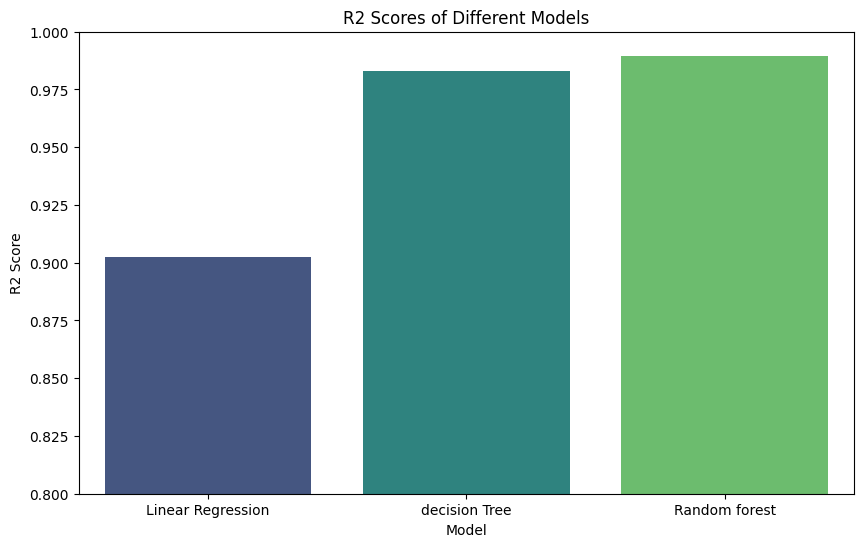

In [ ]:
#Visualization of all 3 model
model_names = list(result.keys())
r2_scores = list(result.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=r2_scores, palette='viridis')
plt.title('R2 Scores of Different Models')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.ylim(0.8, 1.0)

MODEL PERFORMANCE INSIGHTS (POINTS)

All models achieved high accuracy with R² scores above 0.90

Linear Regression showed the lowest performance (~0.90 R²)

Linear Regression is less effective for complex or non-linear data

Decision Tree performed better with ~0.98 R² score

Decision Tree can capture non-linear relationships in the data

Random Forest achieved the highest accuracy (~0.99 R²)

Random Forest is the best-performing model

Ensemble methods like Random Forest improve prediction accuracy

Random Forest helps in reducing overfitting

The dataset contains complex patterns, better handled by tree-based models